# Análise Exploratória de Dados — Customer Support Ticket Dataset

**Projeto de Bloco: Análise e Segurança de Agentes de IA**

---

## 1. Compreensão do problema e do dataset

### 1.1 Contexto do projeto

O objetivo do bloco é construir um **sistema de atendimento ao cliente alimentado por IA**: um
agente que recebe a mensagem de um cliente e identifica a **intenção** por trás dela (problema
técnico, cobrança, reembolso, dúvida de produto, cancelamento), para então encaminhar ou responder
adequadamente. A etapa atual (**TP1**) antecede qualquer modelagem: escolher o dataset, entendê-lo
com rigor estatístico e preparar a base que sustentará o modelo e a API.

**Perguntas que este EDA deve responder:**

1. O que o dataset representa e de onde veio?
2. Qual a qualidade dos dados? O que precisa de limpeza antes da modelagem?
3. Como se distribuem as variáveis-chave — em especial as que descrevem a *intenção* do cliente?
4. Que hipóteses sobre o comportamento dos usuários os padrões observados sustentam?

### 1.2 Documentação técnica do dataset (Tarefa 1)

**Fonte (origem):** [Customer Support Ticket Dataset](https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset),
publicado por Suraj na plataforma Kaggle. Licença **CC0: Public Domain** (uso livre, inclusive comercial).
Arquivo único: `customer_support_tickets.csv` (~3,9 MB, 8.469 registros × 17 colunas).

**Principais características:**

| Dimensão | Característica |
|---|---|
| Domínio | Tickets de suporte ao cliente de produtos de tecnologia (laptops, smartphones, TVs, acessórios) |
| Granularidade | 1 linha = 1 ticket |
| Texto livre | `Ticket Subject` (assunto curto) e `Ticket Description` (descrição longa) — insumo para NLP |
| Alvo potencial | `Ticket Type` — 5 intenções: technical issue, billing inquiry, product inquiry, refund request, cancellation request |
| Dimensões de contexto | Cliente (idade, gênero), produto, status, prioridade, canal, tempos de resposta/resolução, satisfação (1–5) |
| Natureza | Sintética (ver Seção 3 — há artefatos claros de geração automática) |
| Casos de uso declarados | Análise de tendências de suporte, classificação de tickets via NLP, predição de satisfação e de tempo de resolução, segmentação de clientes |

**Motivo da escolha do dataset:**

1. **Aderência direta ao objetivo do bloco.** O dataset combina texto livre do cliente (`Ticket
   Description`, `Ticket Subject`) com rótulos de intenção (`Ticket Type`) — exatamente a matéria-prima
   de um agente de atendimento com IA: dado um texto, inferir a intenção.
2. **Riqueza de dimensões de contexto.** Além do texto, há canal, prioridade, status, satisfação e
   tempos de atendimento — permite enriquecer o modelo e medir o impacto do sistema (ex.: satisfação
   por canal) em etapas futuras.
3. **Variável-alvo bem definida e multiclasse.** 5 intenções balanceadas (~20% cada) configuram um
   problema de classificação realista, com métricas interpretáveis.
4. **Licença CC0 e distribuição pública.** Sem restrições legais para uso acadêmico e para o
   repositório público exigido na entrega.

### 1.3 Dicionário de variáveis

| Variável | Tipo | Descrição |
|---|---|---|
| `Ticket ID` | int | Identificador único do ticket |
| `Customer Name` | str | Nome do cliente |
| `Customer Email` | str | E-mail do cliente (domínio `@example.com` — anonimização intencional) |
| `Customer Age` | int | Idade do cliente (18–70) |
| `Customer Gender` | str | Gênero: Male / Female / Other |
| `Product Purchased` | str | Produto adquirido (42 produtos distintos) |
| `Date of Purchase` | str→date | Data da compra |
| `Ticket Type` | str | **Tipo/intenção do ticket** (5 classes) — alvo da classificação |
| `Ticket Subject` | str | Assunto resumido do ticket (16 assuntos) |
| `Ticket Description` | str | Descrição textual detalhada do problema |
| `Ticket Status` | str | Status: Open / Pending Customer Response / Closed |
| `Resolution` | str | Solução registrada (apenas tickets fechados) |
| `Ticket Priority` | str | Prioridade: Low / Medium / High / Critical |
| `Ticket Channel` | str | Canal: Email / Phone / Chat / Social media |
| `First Response Time` | str→datetime | Timestamp da primeira resposta |
| `Time to Resolution` | str→datetime | Timestamp da resolução (apenas tickets fechados) |
| `Customer Satisfaction Rating` | float | Satisfação do cliente, escala 1–5 (apenas tickets fechados) |

## 2. Inspeção inicial

In [ ]:
# Setup
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Design tokens
INK = "#0b0b0b"        # texto primário
INK2 = "#52514e"       # texto secundário
MUTED = "#898781"      # rótulos de eixo
GRID = "#e1e0d9"       # linhas de grade
AXIS = "#c3c2b7"       # linha de base dos eixos
SURFACE = "#fcfcfb"    # fundo do gráfico
BLUE = "#2a78d6"       # hue sequencial (única cor para magnitude)

# Cores categóricas em ordem fixa atribuídas à
# ENTIDADE (Ticket Type), nunca à posição no ranking.
TYPE_COLORS = {
    "Billing inquiry": "#2a78d6",
    "Cancellation request": "#eb6834",
    "Product inquiry": "#1baf7a",
    "Refund request": "#eda100",
    "Technical issue": "#e87ba4",
}
# Rampa ordinal (prioridade): passos 250→650 da paleta sequencial azul.
PRIORITY_RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#104281"]

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": AXIS,
        "axes.linewidth": 1.0,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "text.color": INK,
        "xtick.color": INK2,
        "ytick.color": INK2,
        "xtick.labelcolor": INK2,
        "ytick.labelcolor": INK2,
        "grid.color": GRID,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "figure.dpi": 110,
    }
)


def style_ax(ax):
    """Chrome padrão: remove spines superiores/direitos, grade horizontal recessiva."""
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)


def label_bars(ax, container, fmt="{:,}"):
    """Rótulos diretos sobre as barras (regra de alívio de contraste: identidade nunca depende só de cor)."""
    ax.bar_label(container, fmt=fmt, color=INK, fontsize=9, fontweight="bold", padding=3)


DATA_PATH = "../data/customer_support_tickets.csv"

In [ ]:
df = pd.read_csv(DATA_PATH)
print(f"Formato: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
df.head(3)

Formato: 8,469 linhas × 17 colunas


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


In [ ]:
df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [ ]:
# Cardinalidade: quantos valores únicos por coluna?
pd.DataFrame(
    {
        "únicos": df.nunique(),
        "tipo": df.dtypes.astype(str),
    }
)

,únicos,tipo
Ticket ID,8469,int64
Customer Name,8028,str
Customer Email,8320,str
Customer Age,53,int64
Customer Gender,3,str
Product Purchased,42,str
Date of Purchase,730,str
Ticket Type,5,str
Ticket Subject,16,str
Ticket Description,8077,str


In [ ]:
# Estatísticas descritivas das variáveis numéricas
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Ticket ID,8469.0,4235.00,2444.93,1.0,2118.0,4235.0,6352.0,8469.0
Customer Age,8469.0,44.03,15.30,18.0,31.0,44.0,57.0,70.0
Customer Satisfaction Rating,2769.0,2.99,1.41,1.0,2.0,3.0,4.0,5.0


**Leitura inicial:** 8.469 tickets; apenas 2 variáveis verdadeiramente numéricas (`Customer Age` e
`Customer Satisfaction Rating`); o restante é categórico ou texto. `Resolution`, `Time to Resolution`
e `Customer Satisfaction Rating` têm 5.700 nulos cada (indício de nulidade **estrutural**: campos que só existem para tickets fechados, o que a Seção 3 confirma).

## 3. Verificação da qualidade dos dados

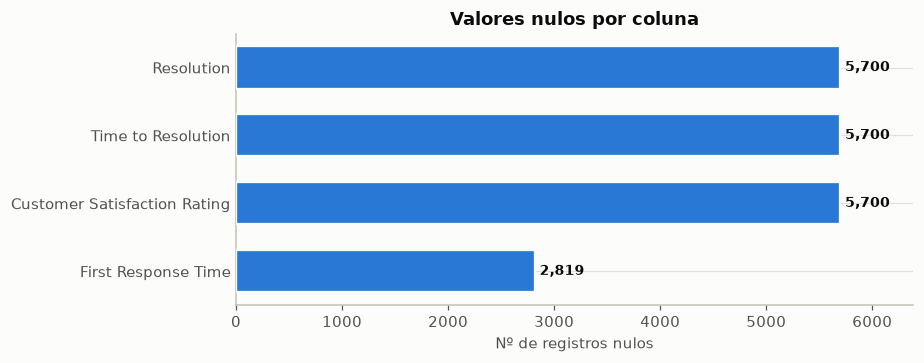

Nulos totais: 19919 (13.84% das células)


In [ ]:
# Nulos por coluna
nulls = df.isna().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8.5, 3.4))
style_ax(ax)
bars = ax.barh(
    nulls.index[::-1],
    nulls.values[::-1],
    color=BLUE,
    height=0.62,
    edgecolor=SURFACE,
    linewidth=1.5,
    zorder=3,
)
label_bars(ax, bars)
ax.set_title("Valores nulos por coluna")
ax.set_xlabel("Nº de registros nulos")
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, nulls.max() * 1.12)
plt.tight_layout()
plt.show()

print("Nulos totais:", df.isna().sum().sum(), f"({df.isna().sum().sum() / df.size:.2%} das células)")

In [ ]:
# Duplicatas e integridade de IDs
print(f"Linhas duplicadas: {df.duplicated().sum()}")
print(f"Ticket ID único: {df['Ticket ID'].is_unique} | range: {df['Ticket ID'].min()}–{df['Ticket ID'].max()} (esperado 1–8469)")

# Ranges lógicos das numéricas
print(f"\nIdade: min {df['Customer Age'].min()} | max {df['Customer Age'].max()} (admissível 18–70)")
print(f"Rating: valores presentes {sorted(df['Customer Satisfaction Rating'].dropna().unique())} (escala 1–5)")

# Nulidade estrutural: os nulos casam com o status do ticket?
print(f"\nTickets Closed: {(df['Ticket Status'] == 'Closed').sum()}")
print(f"Tickets Closed com Rating preenchido: {df.loc[df['Ticket Status'] == 'Closed', 'Customer Satisfaction Rating'].notna().sum()}")
print(f"Tickets Closed com Time to Resolution: {df.loc[df['Ticket Status'] == 'Closed', 'Time to Resolution'].notna().sum()}")
print(f"Tickets NÃO Closed com Rating preenchido: {df.loc[df['Ticket Status'] != 'Closed', 'Customer Satisfaction Rating'].notna().sum()}")

Linhas duplicadas: 0
Ticket ID único: True | range: 1–8469 (esperado 1–8469)

Idade: min 18 | max 70 (admissível 18–70)
Rating: valores presentes [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)] (escala 1–5)

Tickets Closed: 2769
Tickets Closed com Rating preenchido: 2769
Tickets Closed com Time to Resolution: 2769
Tickets NÃO Closed com Rating preenchido: 0


In [ ]:
# Artefatos de geração sintética
placeholder = df["Ticket Description"].str.contains("{product_purchased}", regex=False).mean()
template = df["Ticket Description"].str.contains("I'm having an issue", regex=False).mean()
print(f"Descrições contendo placeholder '{{product_purchased}}': {placeholder:.0%}")
print(f"Descrições seguindo o template 'I'm having an issue...': {template:.0%}")
print(f"Comprimento médio da descrição: {df['Ticket Description'].str.len().mean():.0f} caracteres")

purchase = pd.to_datetime(df["Date of Purchase"])
first_resp = pd.to_datetime(df["First Response Time"], errors="coerce")
resolution = pd.to_datetime(df["Time to Resolution"], errors="coerce")
print(f"\nJanela de compras: {purchase.min().date()} → {purchase.max().date()}")
print(f"Janela de primeira resposta: {first_resp.min()} → {first_resp.max()}  (~2,5 dias!)")
print(f"Janela de resolução: {resolution.min()} → {resolution.max()}  (~2,5 dias!)")

# Consistência temporal: resolução ANTES da primeira resposta?
delta_h = (resolution - first_resp).dt.total_seconds() / 3600
print(f"\nResolução − primeira resposta (horas): min {delta_h.min():.1f} | mediana {delta_h.median():.1f} | max {delta_h.max():.1f}")
print(f"Casos em que a resolução é ANTERIOR à primeira resposta: {(delta_h < 0).mean():.0%}")

Descrições contendo placeholder '{product_purchased}': 100%
Descrições seguindo o template 'I'm having an issue...': 69%
Comprimento médio da descrição: 290 caracteres

Janela de compras: 2020-01-01 → 2021-12-30
Janela de primeira resposta: 2023-05-31 21:55:39 → 2023-06-02 00:54:21  (~2,5 dias!)
Janela de resolução: 2023-05-31 21:53:30 → 2023-06-02 00:55:33  (~2,5 dias!)

Resolução − primeira resposta (horas): min -23.2 | mediana 0.2 | max 23.5
Casos em que a resolução é ANTERIOR à primeira resposta: 16%


In [ ]:
# Privacidade (anônimização declarada na documentação)
print(f"E-mails em @example.com: {df['Customer Email'].str.contains('@example.com').mean():.0%}")

E-mails em @example.com: 34%


### Síntese da qualidade dos dados

| Achado | Severidade | Decisão |
|---|---|---|
| 5.700 nulos em `Resolution`, `Time to Resolution`, `Customer Satisfaction Rating` | **Estrutural, não é defeito** | Os 3 campos existem *apenas* para os 2.769 tickets `Closed` (cobertura 100% dentro do status). **Manter**, pois nulidade carrega informação de status. |
| 2.819 nulos em `First Response Time` | Estrutural | Tickets ainda sem resposta no momento do snapshot. **Manter.** |
| `{product_purchased}` em 100% das descrições | Alto (texto) | Artefato de template de geração. **Corrigir** substituindo pelo produto real. Em caso contrário, o NLP aprenderia o token em vez do conteúdo. |
| ~69% das descrições seguem template fixo ("I'm having an issue...") | Médio (documentado) | Limitação sintética do corpus; **documentar** e considerar na modelagem. |
| Resolução **anterior** à primeira resposta em ~83% dos casos | Médio | Timestamps não obedecem a causalidade → geração sintética. **Documentar**; não derivar SLA dos timestamps. |
| Tickets concentrados em ~2,5 dias (31/mai–02/jun/2023) vs. compras em 2020–2021 | Médio | Ausência de sazonalidade real; janela única de geração. **Documentar.** |
| 0 duplicatas; IDs íntegros (1–8.469); idade e rating dentro dos ranges | — | Nenhuma ação. |
| E-mails anonimizados (`@example.com`) | — | Intencional (privacidade); nenhuma ação. |

## 4. Limpeza e preparação dos dados

Operações aplicadas (mínimas e justificadas):

1. **Tipagem temporal:** `Date of Purchase`, `First Response Time`, `Time to Resolution` → `datetime64`.
2. **Correção do placeholder:** substituir `{product_purchased}` pelo nome real do produto na descrição.
3. **Variáveis derivadas** para a análise univariada: hora do dia da primeira resposta;
   tempo compra→ticket em meses (usando 2023-06-01 como referência da janela única de tickets).
4. **Sem imputação:** os nulos são estruturais (Seção 3); imputá-los destruiria informação.
5. **Sem remoção de registros:** nenhum ticket é inválido para a análise.

In [ ]:
# Limpeza
clean = (
    df.assign(
        **{
            "Date of Purchase": pd.to_datetime(df["Date of Purchase"]),
            "First Response Time": pd.to_datetime(df["First Response Time"], errors="coerce"),
            "Time to Resolution": pd.to_datetime(df["Time to Resolution"], errors="coerce"),
            # placeholder → produto real
            "Ticket Description": [
                desc.replace("{product_purchased}", prod)
                for desc, prod in zip(df["Ticket Description"], df["Product Purchased"])
            ],
        }
    )
    .assign(
        # derivadas
        Hour_of_First_Response=lambda d: d["First Response Time"].dt.hour,
        Purchase_to_Ticket_Months=lambda d: (
            pd.Timestamp("2023-06-01") - d["Date of Purchase"]
        ).dt.days / 30.44,
    )
)

# Sanidade: placeholder eliminado? Novas colunas presentes?
print(f"Placeholders restantes: {clean['Ticket Description'].str.contains('{product_purchased}', regex=False).sum()}")
print(f"Novas colunas: {clean[['Hour_of_First_Response', 'Purchase_to_Ticket_Months']].dtypes.to_dict()}")

# Persistir versão limpa (mantém-se o arquivo original em data/)
clean.to_csv("../data/customer_support_tickets_clean.csv", index=False)
print("Versão limpa salva em data/customer_support_tickets_clean.csv")

Placeholders restantes: 0
Novas colunas: {'Hour_of_First_Response': dtype('float64'), 'Purchase_to_Ticket_Months': dtype('float64')}
Versão limpa salva em data/customer_support_tickets_clean.csv


## 5. Análise Univariada

Distribuições das principais variáveis, com foco nas dimensões ligadas à **intenção** do usuário:
`Ticket Type` (alvo), `Ticket Subject` (assunto), canal, prioridade, status, produto, idade,
satisfação e padrões temporais.

### 5.1 Variáveis categóricas

**`Ticket Type`: o alvo de intenção.** As 5 classes recebem cores categóricas fixas
(slots 1–5 da paleta validada), atribuídas à entidade. O gráfico abaixo define o mapa de cores
usado em todo o notebook para esta variável.

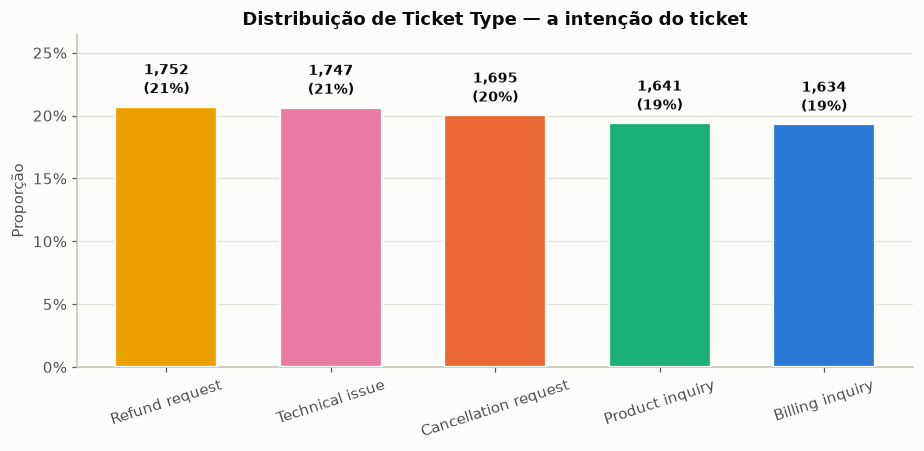

Amplitude entre classes: 1.4%


In [ ]:
type_counts = clean["Ticket Type"].value_counts(normalize=True).sort_values(ascending=False)
type_counts_n = clean["Ticket Type"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
style_ax(ax)
colors = [TYPE_COLORS[t] for t in type_counts.index]
bars = ax.bar(
    type_counts.index,
    type_counts.values,
    color=colors,
    width=0.62,
    edgecolor=SURFACE,
    linewidth=1.5,
    zorder=3,
)
# rótulo com contagem + percentual
for b, pct, n in zip(bars, type_counts.values, type_counts_n.values):
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.008,
        f"{n:,}\n({pct:.0%})",
        ha="center",
        va="bottom",
        color=INK,
        fontsize=9,
        fontweight="bold",
        linespacing=1.3,
    )
ax.set_ylim(0, type_counts.max() * 1.28)
ax.set_title("Distribuição de Ticket Type — a intenção do ticket")
ax.set_xlabel("")
ax.set_ylabel("Proporção")
ax.tick_params(axis="x", labelrotation=18)
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.tight_layout()
plt.show()

print("Amplitude entre classes:", f"{(type_counts.max() - type_counts.min()):.1%}")

**`Ticket Subject`** — granularidade mais fina da intenção (16 assuntos). Distribuição praticamente
uniforme, coerente com o `Ticket Type` equilibrado.

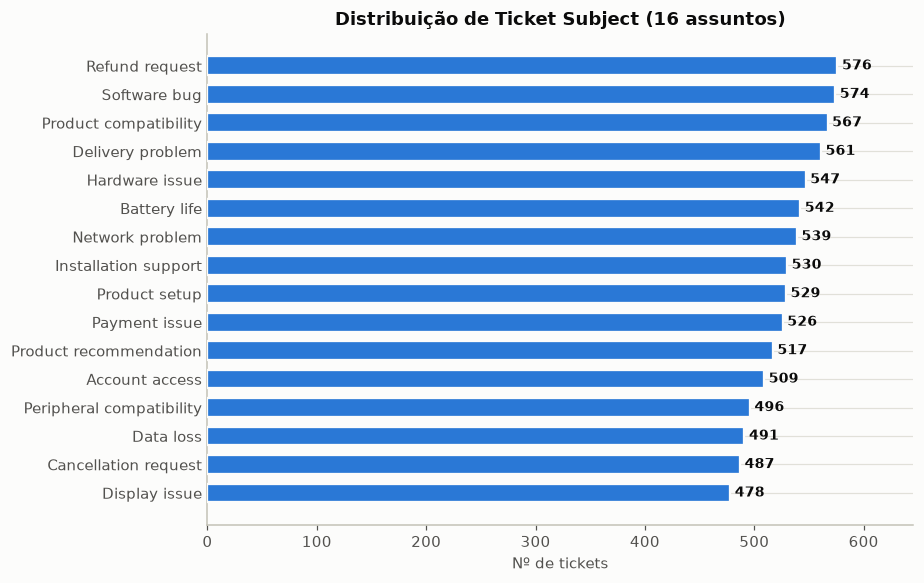

In [ ]:
subj = clean["Ticket Subject"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8.5, 5.4))
style_ax(ax)
bars = ax.barh(subj.index, subj.values, color=BLUE, height=0.66, edgecolor=SURFACE, linewidth=1.5, zorder=3)
label_bars(ax, bars)
ax.set_title("Distribuição de Ticket Subject (16 assuntos)")
ax.set_xlabel("Nº de tickets")
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, subj.max() * 1.12)
plt.tight_layout()
plt.show()

**Status, canal e gênero**: perfis quase uniformes nas três dimensões. Destaque: só **1/3** dos
tickets está `Closed`; e **~75%** dos contatos entram por canais digitais de texto
(Email + Chat + Social media).

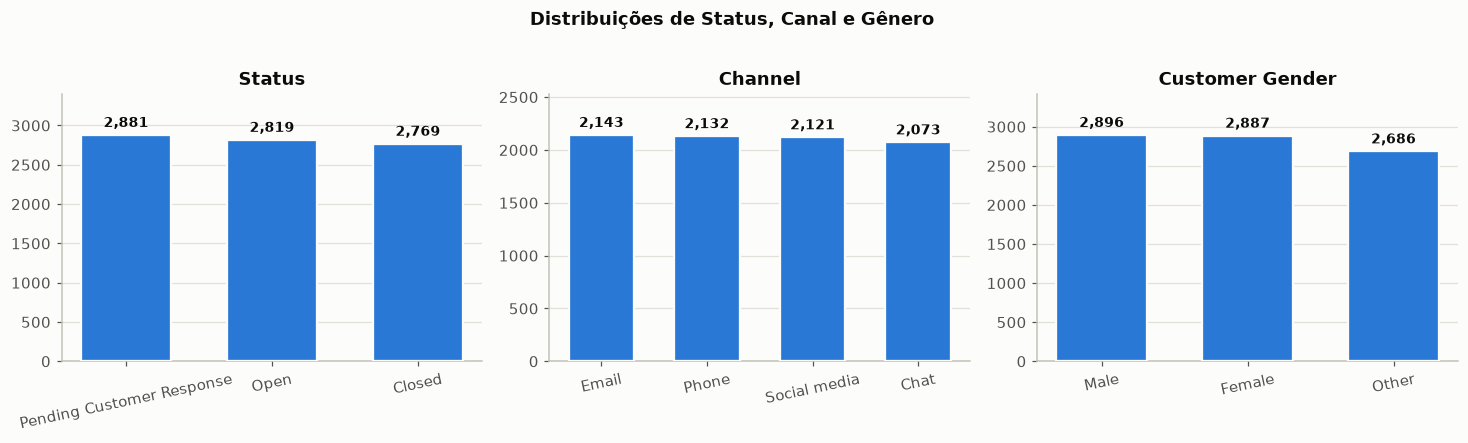

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))
for ax, col in zip(axes, ["Ticket Status", "Ticket Channel", "Customer Gender"]):
    vc = clean[col].value_counts().sort_values(ascending=False)
    style_ax(ax)
    bars = ax.bar(vc.index, vc.values, color=BLUE, width=0.62, edgecolor=SURFACE, linewidth=1.5, zorder=3)
    label_bars(ax, bars)
    ax.set_title(col.replace("Customer Gender", "Customer Gender").replace("Ticket ", ""))
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelrotation=12)
    ax.set_ylim(0, vc.max() * 1.18)
fig.suptitle("Distribuições de Status, Canal e Gênero", fontweight="bold", color=INK, y=1.02)
plt.tight_layout()
plt.show()

**`Ticket Priority`**: variável **ordinal**; a cor usa a rampa sequencial azul (passos 250→650),
na ordem Low → Critical, e não as cores categóricas.

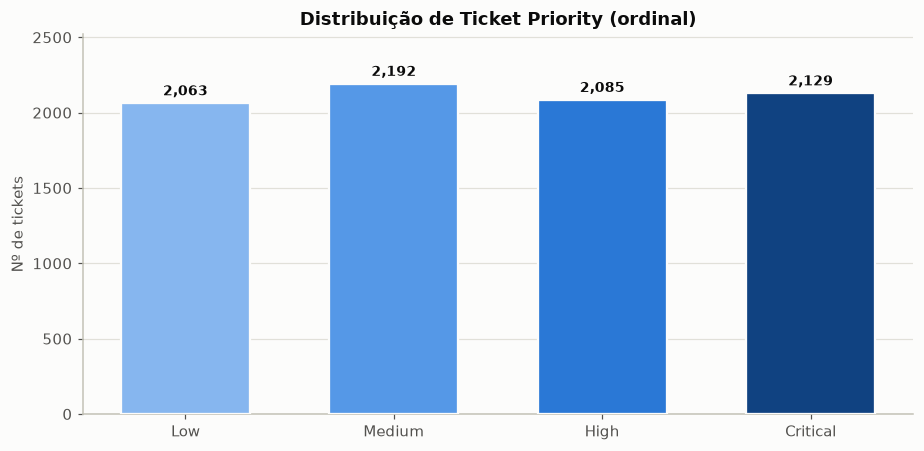

Prioridade alta (High + Critical): 50% dos tickets


In [ ]:
prio_order = ["Low", "Medium", "High", "Critical"]
prio = clean["Ticket Priority"].value_counts().reindex(prio_order)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
style_ax(ax)
bars = ax.bar(prio.index, prio.values, color=PRIORITY_RAMP, width=0.62, edgecolor=SURFACE, linewidth=1.5, zorder=3)
label_bars(ax, bars)
ax.set_title("Distribuição de Ticket Priority (ordinal)")
ax.set_xlabel("")
ax.set_ylabel("Nº de tickets")
ax.set_ylim(0, prio.max() * 1.15)
plt.tight_layout()
plt.show()

print(f"Prioridade alta (High + Critical): {prio[['High', 'Critical']].sum() / prio.sum():.0%} dos tickets")

**`Product Purchased`**: cauda longa composta por 42 produtos e nenhum concentra demanda (o top-1 tem ~2,8%).
Exibidos os 10 maiores; os 32 restantes são agregados em "Outros (32 produtos)".

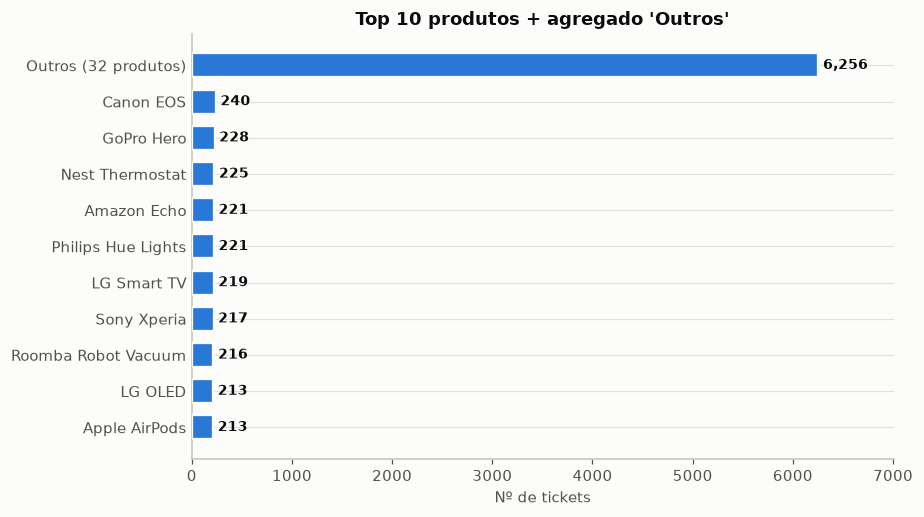

In [ ]:
prod = clean["Product Purchased"].value_counts()
top10 = prod.head(10)
others = prod.iloc[10:].sum()
prod_plot = pd.concat([top10, pd.Series({"Outros (32 produtos)": others})]).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 4.8))
style_ax(ax)
bars = ax.barh(prod_plot.index, prod_plot.values, color=BLUE, height=0.66, edgecolor=SURFACE, linewidth=1.5, zorder=3)
label_bars(ax, bars)
ax.set_title("Top 10 produtos + agregado 'Outros'")
ax.set_xlabel("Nº de tickets")
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, prod_plot.max() * 1.12)
plt.tight_layout()
plt.show()

### 5.2 Variáveis numéricas — histogramas

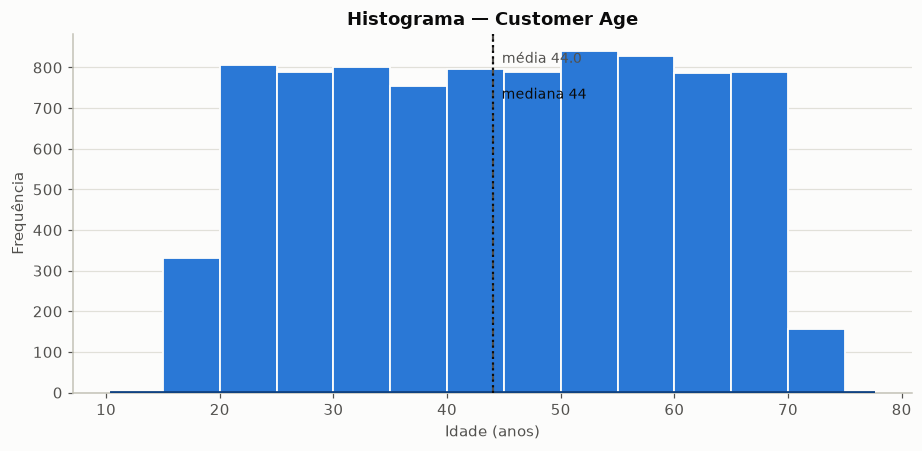

Idade: média 44.0 | mediana 44 | desvio-padrão 15.3 | min 18 | max 70


In [ ]:
# Idade
age = clean["Customer Age"]
bins = np.arange(15, 76, 5)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
style_ax(ax)
ax.hist(
    age,
    bins=bins,
    color=BLUE,
    edgecolor=SURFACE,
    linewidth=1.2,
    zorder=3,

)
sns.kdeplot(age, ax=ax, color="#104281", linewidth=2, zorder=4)
ax.axvline(age.mean(), color=INK2, linestyle="--", linewidth=1.4, zorder=5)
ax.axvline(age.median(), color=INK, linestyle=":", linewidth=1.4, zorder=5)
ax.text(age.mean() + 0.8, ax.get_ylim()[1] * 0.92, f"média {age.mean():.1f}", color=INK2, fontsize=9)
ax.text(age.median() + 0.8, ax.get_ylim()[1] * 0.82, f"mediana {age.median():.0f}", color=INK, fontsize=9)
ax.set_title("Histograma — Customer Age")
ax.set_xlabel("Idade (anos)")
ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

print(f"Idade: média {age.mean():.1f} | mediana {age.median():.0f} | desvio-padrão {age.std():.1f} | min {age.min()} | max {age.max()}")

**`Customer Satisfaction Rating`**: disponível apenas para tickets fechados (2.769). Escala discreta
1–5, praticamente uniforme: a satisfação média é baixa (3,0), com 1/3 dos clientes avaliando com 1 ou 2.

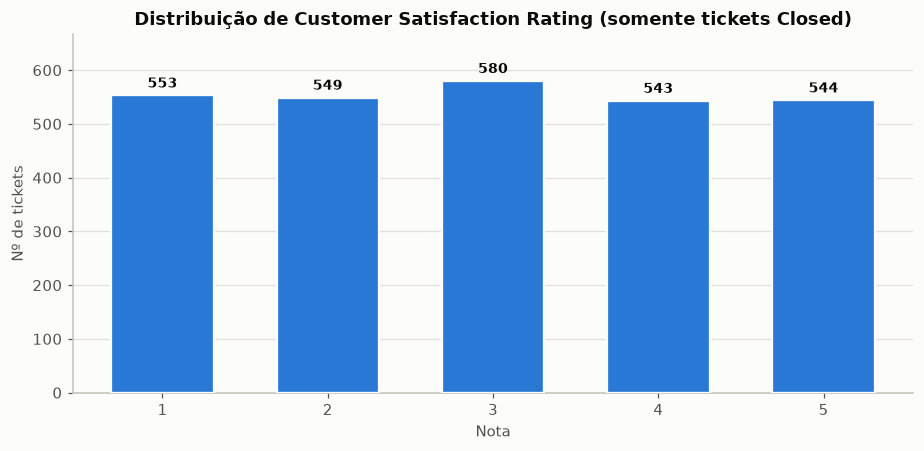

Satisfação média: 2.99 | notas 1–2: 40% | notas 4–5: 39%


In [ ]:
rating = clean["Customer Satisfaction Rating"].dropna().astype(int)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
style_ax(ax)
vc = rating.value_counts().reindex([1, 2, 3, 4, 5])
bars = ax.bar(vc.index.astype(str), vc.values, color=BLUE, width=0.62, edgecolor=SURFACE, linewidth=1.5, zorder=3)
label_bars(ax, bars)
ax.set_title("Distribuição de Customer Satisfaction Rating (somente tickets Closed)")
ax.set_xlabel("Nota")
ax.set_ylabel("Nº de tickets")
ax.set_ylim(0, vc.max() * 1.15)
plt.tight_layout()
plt.show()

print(f"Satisfação média: {rating.mean():.2f} | notas 1–2: {(rating <= 2).mean():.0%} | notas 4–5: {(rating >= 4).mean():.0%}")

**Hora da primeira resposta**: há atendimento em todas as faixas do dia, com leve elevação nas
primeiras horas da madrugada (artefato de geração). A janela total é de apenas ~2,5 dias
(31/mai–02/jun/2023), então este padrão não reflete sazonalidade real.

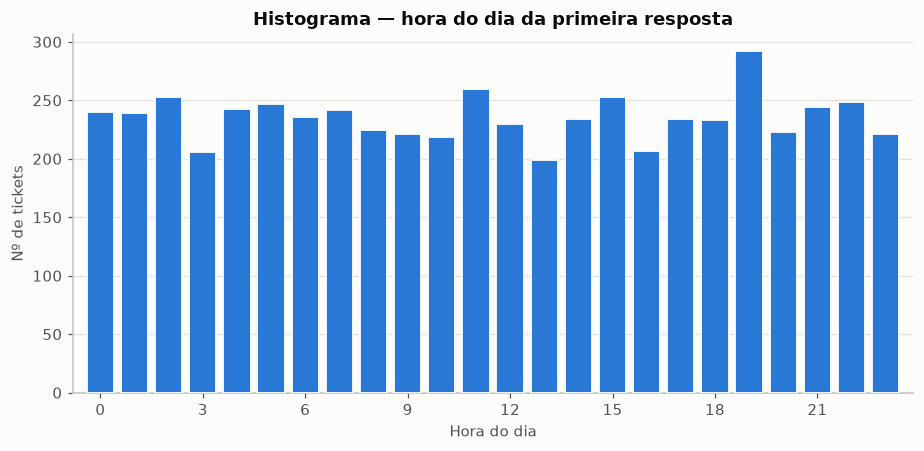

Tickets com primeira resposta registrada: 5,650 (100%)


In [ ]:
hour = clean["Hour_of_First_Response"].dropna()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
style_ax(ax)
counts = hour.value_counts().reindex(range(24), fill_value=0)
ax.bar(counts.index, counts.values, color=BLUE, width=0.8, edgecolor=SURFACE, linewidth=1.2, zorder=3)
ax.set_title("Histograma — hora do dia da primeira resposta")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Nº de tickets")
ax.set_xticks(range(0, 24, 3))
ax.set_xlim(-0.8, 23.8)
plt.tight_layout()
plt.show()

print(f"Tickets com primeira resposta registrada: {hour.notna().sum():,} ({hour.notna().mean():.0%})")

**Tempo compra → ticket** (referência: centro da janela única de tickets, 2023-06-01). Todos os
clientes compraram entre 2020 e 2021 e abriram ticket ~2 anos depois — padrão incompatível com
atendimento real e evidência adicional da geração sintética.

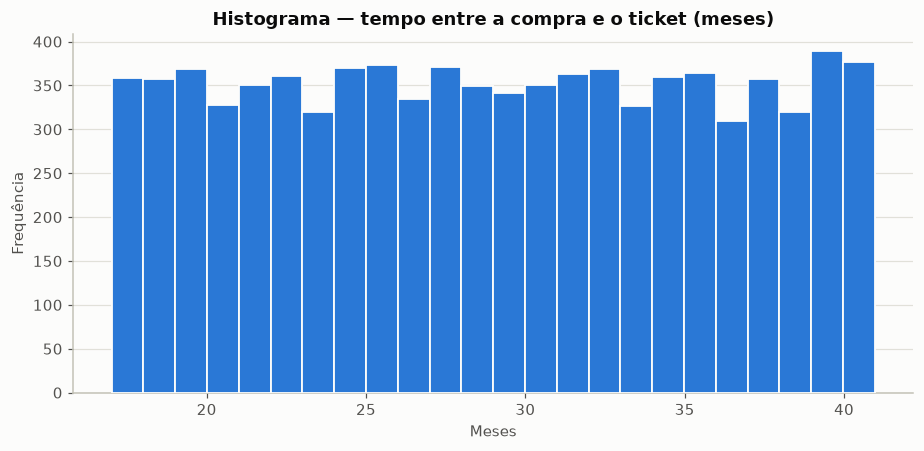

Tempo compra→ticket: min 17 | mediana 29 | max 41 meses


In [ ]:
lag = clean["Purchase_to_Ticket_Months"]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
style_ax(ax)
ax.hist(
    lag,
    bins=24,
    color=BLUE,
    edgecolor=SURFACE,
    linewidth=1.2,
    zorder=3,

)
ax.set_title("Histograma — tempo entre a compra e o ticket (meses)")
ax.set_xlabel("Meses")
ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

print(f"Tempo compra→ticket: min {lag.min():.0f} | mediana {lag.median():.0f} | max {lag.max():.0f} meses")

## 6. Hipóteses sobre as intenções dos usuários

A partir dos padrões observados na análise univariada, formulam-se **5 hipóteses** sobre as
intenções dos usuários. Cada hipótese associa o padrão observado → interpretação de intenção →
implicação para o sistema de IA do bloco.

### H1 — As intenções são equilibradas: não existe intenção dominante
**Padrão:** as 5 classes de `Ticket Type` variam entre 19,3% e 20,7% (amplitude de 1,4 pp); os 16
assuntos variam entre 6,0% e 6,8%.
**Hipótese:** a demanda de suporte se distribui uniformemente entre intenções técnicas, financeiras
e comerciais, ou seja, nenhuma delas domina o atendimento.
**Implicação:** o classificador enfrenta um problema multiclasse **balanceado**; acurácia é uma
métrica válida (baseline aleatório ≈ 20%) e o agente precisa cobrir as 5 intenções com igual
qualidade, assim sendo otimizar para uma classe só não é uma estratégia vencedora.

### H2 — A prioridade declarada não reflete a intenção real de urgência
**Padrão:** prioridades quase uniformes (~24,4%–25,9% cada), com ~50% dos tickets `High`/`Critical`,
enquanto apenas 33% dos tickets foram fechados.
**Hipótese:** a urgência declarada é inflada (ou distribuída aleatoriamente) e não acompanha a
capacidade real de resolução; a intenção do usuário ao abrir o ticket não é predita pela prioridade.
**Implicação:** `Ticket Priority` deve ser tratada como variável de baixa confiança para o modelo;
a priorização do agente deve derivar da intenção classificada (e, depois, do sentimento), não do rótulo original.

### H3 — A intenção de contato é majoritariamente textual e digital
**Padrão:** ~75% dos tickets chegam por canais digitais de texto (Email 25,3%, Social media 25,0%,
Chat 24,5%) contra ~25% por telefone.
**Hipótese:** o usuário médio prefere expressar sua intenção **por escrito e de forma assíncrona**,
em vez de falar ao telefone.
**Implicação:** valida a arquitetura do projeto; um agente baseado em NLP sobre texto cobre a via
preferencial do usuário; o telefone é canal secundário.

### H4 — A intenção é definida pelo tipo de problema, não pelo produto
**Padrão:** 42 produtos com cauda longa (top-1 ≈ 2,8% dos tickets); nenhum produto concentra demanda.
**Hipótese:** a intenção do usuário é transversal ao portfólio, o que varia é o *assunto*
(software, cobrança, entrega, configuração), não o equipamento específico.
**Implicação:** o modelo pode generalizar sem features específicas de produto; as variáveis textuais
(`Subject`/`Description`) e `Ticket Type` devem ser os sinais centrais da classificação.

### H5 — O texto bruto das descrições é insuficiente para inferir intenção
**Padrão:** 100% das descrições contêm o placeholder `{product_purchased}` (corrigido na limpeza) e
~69% seguem o mesmo template ("I'm having an issue..."); toda a janela de tickets cabe em ~2,5 dias,
com resoluções cronologicamente anteriores a primeiras respostas em 83% dos casos.
**Hipótese:** as descrições são geradas sinteticamente e os padrões lexicais de template dominam o
texto; a "intenção" observável no texto bruto é, em grande parte, artefato de geração.
**Implicação:** modelar a intenção **a partir do texto bruto é arriscado** (overfitting lexical em
templates); a estratégia robusta é usar `Ticket Subject`/`Ticket Type` como rótulo e tratar a
descrição com normalização de templates, ou validar o ganho do texto sobre um baseline
sujeito+tipo em etapa futura.

**Síntese:** o dataset sustenta o problema de classificação de intenções, com as ressalvas de que
(i) prioridade e timestamps são sinais de baixa confiança e (ii) o texto precisa de preparação
antes de alimentar qualquer modelo.

## 7. Elabore um DFD básico da API com as entradas, saídas e trust boundaries identificados. Aplique a tríade CIA para cada componente: o que é confidencial, o que precisa de integridade, o que deve estar disponível.


### 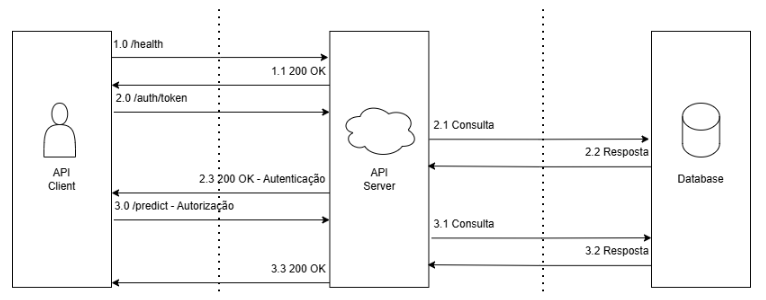

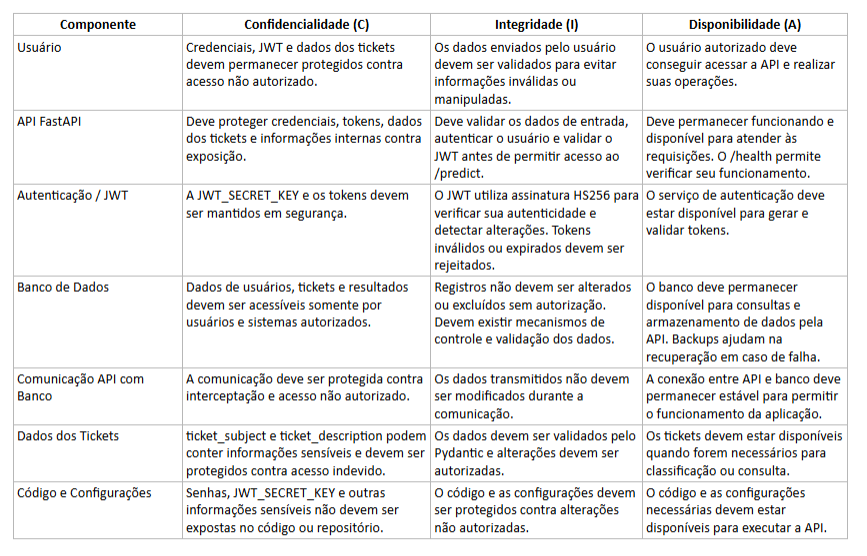